In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from opensim_pendulum import OpenSimPendulum

In [2]:
model = OpenSimPendulum()
model._use_gravity = False
model._with_contact = False
model.initialize(0.0)

In [3]:
model.actuator.setOverrideActuation(model.state, 10)
model.model.realizeDynamics(model.state)
model.model.realizeAcceleration(model.state)
model.coord.getAccelerationValue(model.state)

62.49999999999999

In [4]:
state = model.get_state()
state

{'q': {'value': 0.0, 'unit': 'rad'},
 'omega': {'value': 0.0, 'unit': 'rad/s'},
 'alpha': {'value': 62.49999999999999, 'unit': 'rad/s^2'},
 'torque': {'value': 10.0, 'unit': 'N.m'}}

In [5]:
state['torque']['value'] = -20
model.set_state(state, 0)

In [6]:
model.get_state()

{'q': {'value': 0.0, 'unit': 'rad'},
 'omega': {'value': 0.0, 'unit': 'rad/s'},
 'alpha': {'value': -124.99999999999999, 'unit': 'rad/s^2'},
 'torque': {'value': -20.0, 'unit': 'N.m'}}

In [3]:
# viz = osim.VisualizerUtilities()
# viz.showModel(model.model)

In [4]:
# Analytical solution
L = model.parameters['Model']['length']
m = model.parameters['Model']['mass']
I = m * L**2
q0 = model.parameters['InitialConditions']['q0']
omega0 = model.parameters['InitialConditions']['omega0']

def analytic_step(dt, q, omega, torque, I):
    alpha = torque / I
    q_next = q + omega * dt + 0.5 * alpha * dt**2
    omega_next = omega + alpha * dt
    return q_next, omega_next, alpha

In [5]:
t = 0.0
dt = 0.01
t_end = 1

t_vals = [t]
q_vals = [q0]
a_vals = [omega0]
w_vals = [0.0]

q_an_vals = [q0]
w_an_vals = [omega0]
alpha_an_vals = [0.0]

torque_val = 1
q_an = q0
omega_an = omega0

while t < t_end:
    if t < 0.25 * t_end or t > 0.75 * t_end:
        torque = torque_val
    else:
        torque = -torque_val
    
    # Compute analytical solution
    q_an, omega_an, alpha_an = analytic_step(dt, q_an, omega_an, torque, I)
    
    # Perform simulation step
    model.set_inputs({'torque':torque}, t)
    model.do_step(t, dt)
    t_next = t + dt

    a_vals.append(model.outputs['alpha'].get())
    w_vals.append(model.outputs['omega'].get())
    q_vals.append(model.outputs['q'].get())

    q_an_vals.append(q_an)
    w_an_vals.append(omega_an)
    alpha_an_vals.append(alpha_an)

    t_vals.append(t_next)
    t = t_next

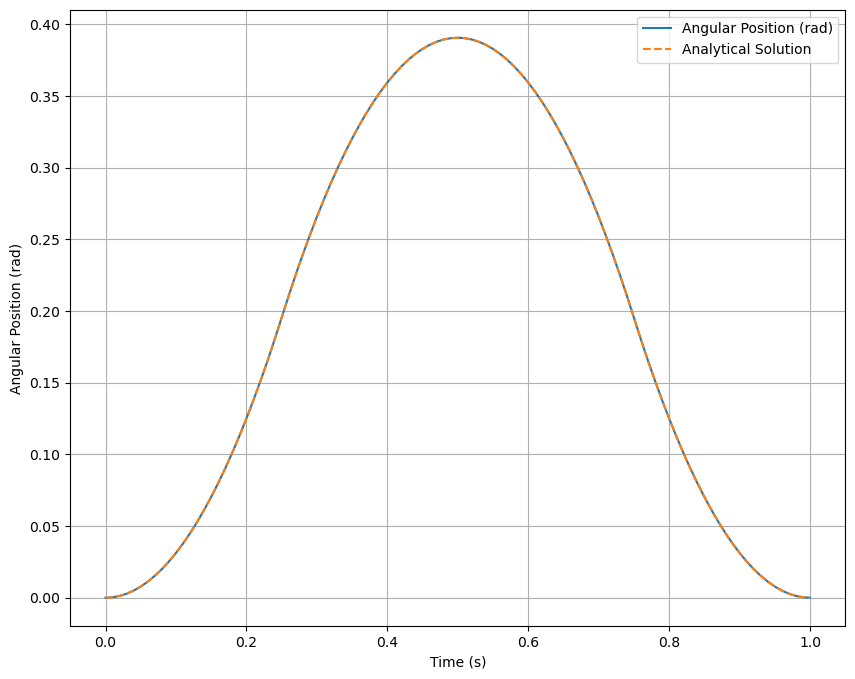

Final Angle (deg): 6.031956353067727×10⁻¹³ deg


In [6]:
plt.figure(figsize=(10, 8))
plt.plot(t_vals, q_vals, label='Angular Position (rad)')
plt.plot(t_vals, q_an_vals, label='Analytical Solution', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (rad)')
plt.grid()
plt.legend()
plt.show()

print(f"Final Angle (deg): {np.rad2deg(model.outputs['q'].get())}")

In [7]:
model.save_model('os_pendulum.osim')